# Reinforcement Learning Fundamentals
## Multi-Armed Bandits & Q-Learning Implementation

**Author:** Vasantha  
**Project:** Reinforcement Learning - Exploration vs Exploitation  
**Date:** March 2026

---

## Project Overview

This notebook implements and analyzes two fundamental reinforcement learning problems:

1. **Multi-Armed Bandit** - Optimizing digital ad campaign performance
2. **Q-Learning in Grid World** - Training a robot to navigate a warehouse

### Key Results

- **Best Bandit Strategy:** Decaying ε-Greedy with 723.1 clicks
- **Q-Learning Performance:** 89.55 average reward, ~10 steps to goal
- **Key Finding:** Domain gap matters more than model complexity

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
print('Libraries loaded!')

Libraries loaded!


---

## <a id="part1"></a>
## Part 1: Multi-Armed Bandit Problem
### Scenario: Digital Ad Campaign Optimization

### Scenario

You are a data scientist at a digital marketing firm. Your client has **5 ad designs** with unknown click-through rates (CTRs). You have **10,000 impressions** to work with. Your goal is to maximize total clicks but you must learn which ad is best by running the campaign, not by testing in advance.

In [2]:
# PROVIDED: Ad Bandit Environment — do not modify
class AdBandit:
    def __init__(self, seed=42):
        np.random.seed(seed)
        self.true_ctrs = [0.02, 0.05, 0.03, 0.08, 0.04]  # hidden from agent
        self.n_arms = len(self.true_ctrs)
        
    def show_ad(self, ad_index):
        return 1 if np.random.random() < self.true_ctrs[ad_index] else 0

bandit = AdBandit()
print(f'Bandit with {bandit.n_arms} arms (true CTRs hidden from agent)')

Bandit with 5 arms (true CTRs hidden from agent)


### 1.1 Implement Strategies 

Implement all four strategies. Use LLMs freely for this code the implementation is not what Part 1 is primarily grading.

**Required strategies:**
- Random baseline (no learning)
- Epsilon-Greedy — test ε = 0.01, 0.1, and 0.3
- Decaying Epsilon-Greedy — starts at ε=1.0, decays each step toward a minimum
- UCB (Upper Confidence Bound) — exploration bonus based on how infrequently an arm has been tried

In [3]:
# YOUR CODE HERE: Implement Random baseline
# Random Baseline
class RandomStrategy:
    def __init__(self, n_arms):
        self.n_arms = n_arms
        
    def select_arm(self):
        return np.random.randint(0, self.n_arms)
    
    def update(self, arm, reward):
        pass  # Random doesn't learn

In [4]:
# YOUR CODE HERE: Implement Epsilon-Greedy
# Epsilon-Greedy
class EpsilonGreedy:
    def __init__(self, n_arms, epsilon):
        self.n_arms = n_arms
        self.epsilon = epsilon
        self.counts = np.zeros(n_arms)
        self.values = np.zeros(n_arms)
        
    def select_arm(self):
        if np.random.random() < self.epsilon:
            return np.random.randint(0, self.n_arms)
        else:
            return np.argmax(self.values)
    
    def update(self, arm, reward):
        self.counts[arm] += 1
        n = self.counts[arm]
        value = self.values[arm]
        self.values[arm] = value + (reward - value) / n

In [5]:
# YOUR CODE HERE: Implement Decaying Epsilon-Greedy
# Decaying Epsilon-Greedy
class DecayingEpsilonGreedy:
    def __init__(self, n_arms, epsilon_start=1.0, epsilon_min=0.01, decay_rate=0.995):
        self.n_arms = n_arms
        self.epsilon = epsilon_start
        self.epsilon_min = epsilon_min
        self.decay_rate = decay_rate
        self.counts = np.zeros(n_arms)
        self.values = np.zeros(n_arms)
        
    def select_arm(self):
        if np.random.random() < self.epsilon:
            arm = np.random.randint(0, self.n_arms)
        else:
            arm = np.argmax(self.values)
        
        # Decay epsilon
        self.epsilon = max(self.epsilon_min, self.epsilon * self.decay_rate)
        return arm
    
    def update(self, arm, reward):
        self.counts[arm] += 1
        n = self.counts[arm]
        value = self.values[arm]
        self.values[arm] = value + (reward - value) / n

In [6]:
# YOUR CODE HERE: Implement UCB
# UCB score = Q(a) + c * sqrt( ln(t) / N(a) )
# where t = total steps, N(a) = times arm a was pulled
# UCB (Upper Confidence Bound)
class UCB:
    def __init__(self, n_arms, c=2.0):
        self.n_arms = n_arms
        self.c = c
        self.counts = np.zeros(n_arms)
        self.values = np.zeros(n_arms)
        self.t = 0
        
    def select_arm(self):
        self.t += 1
        
        # Try each arm once first
        for arm in range(self.n_arms):
            if self.counts[arm] == 0:
                return arm
        
        # UCB score = Q(a) + c * sqrt(ln(t) / N(a))
        ucb_values = self.values + self.c * np.sqrt(np.log(self.t) / self.counts)
        return np.argmax(ucb_values)
    
    def update(self, arm, reward):
        self.counts[arm] += 1
        n = self.counts[arm]
        value = self.values[arm]
        self.values[arm] = value + (reward - value) / n

### 1.2 Run Experiments 

Run each strategy for 10,000 impressions, averaged over at least 50 independent runs. Track:
- Cumulative clicks over time
- Percentage of impressions where the best ad was shown (optimal arm selection %)

In [7]:
# YOUR CODE HERE: Run all strategies and collect results
def run_experiment(strategy, bandit, n_impressions=10000):
    """Run single experiment, return cumulative clicks and optimal arm %"""
    cumulative_clicks = []
    optimal_selections = []
    total_clicks = 0
    optimal_count = 0
    optimal_arm = 3  # Ad 3 has CTR=0.08 (highest)
    
    for t in range(n_impressions):
        arm = strategy.select_arm()
        reward = bandit.show_ad(arm)
        strategy.update(arm, reward)
        
        total_clicks += reward
        cumulative_clicks.append(total_clicks)
        
        if arm == optimal_arm:
            optimal_count += 1
        optimal_selections.append(100 * optimal_count / (t + 1))
    
    return cumulative_clicks, optimal_selections

# Run all strategies
n_runs = 50
n_impressions = 10000

strategies_config = [
    ('Random', lambda: RandomStrategy(5)),
    ('ε-Greedy (ε=0.01)', lambda: EpsilonGreedy(5, 0.01)),
    ('ε-Greedy (ε=0.1)', lambda: EpsilonGreedy(5, 0.1)),
    ('ε-Greedy (ε=0.3)', lambda: EpsilonGreedy(5, 0.3)),
    ('Decaying ε-Greedy', lambda: DecayingEpsilonGreedy(5)),
    ('UCB (c=2.0)', lambda: UCB(5, c=2.0))
]

results = {}

for name, strategy_fn in strategies_config:
    all_clicks = []
    all_optimal = []
    
    for run in range(n_runs):
        bandit = AdBandit(seed=42 + run)
        strategy = strategy_fn()
        clicks, optimal = run_experiment(strategy, bandit, n_impressions)
        all_clicks.append(clicks)
        all_optimal.append(optimal)
    
    results[name] = {
        'clicks': np.mean(all_clicks, axis=0),
        'optimal': np.mean(all_optimal, axis=0),
        'final_clicks': np.mean([c[-1] for c in all_clicks])
    }

print("Final Average Clicks (over 50 runs):")
for name in results:
    print(f"{name:30s}: {results[name]['final_clicks']:.1f}")

Final Average Clicks (over 50 runs):
Random                        : 444.2
ε-Greedy (ε=0.01)             : 572.6
ε-Greedy (ε=0.1)              : 714.8
ε-Greedy (ε=0.3)              : 680.5
Decaying ε-Greedy             : 723.1
UCB (c=2.0)                   : 515.9


### 1.3 Visualizations 

Create two side-by-side plots:
1. Cumulative clicks vs. impressions for all strategies
2. Optimal arm selection % vs. impressions for all strategies

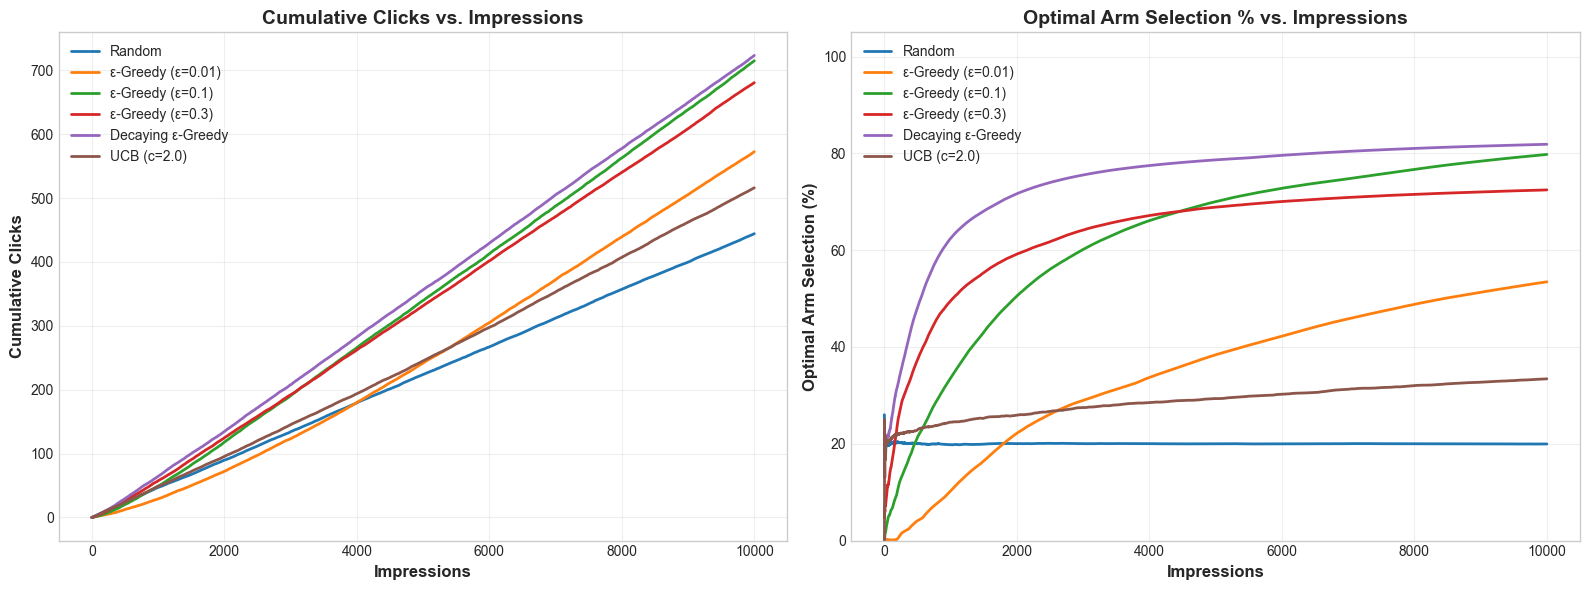

In [8]:
# YOUR CODE HERE: Create both plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Cumulative Clicks
for name in results:
    ax1.plot(results[name]['clicks'], label=name, linewidth=2)
ax1.set_xlabel('Impressions', fontsize=12, fontweight='bold')
ax1.set_ylabel('Cumulative Clicks', fontsize=12, fontweight='bold')
ax1.set_title('Cumulative Clicks vs. Impressions', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Optimal Arm Selection %
for name in results:
    ax2.plot(results[name]['optimal'], label=name, linewidth=2)
ax2.set_xlabel('Impressions', fontsize=12, fontweight='bold')
ax2.set_ylabel('Optimal Arm Selection (%)', fontsize=12, fontweight='bold')
ax2.set_title('Optimal Arm Selection % vs. Impressions', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0, 105])

plt.tight_layout()
plt.show()

### 1.4 Critical Analysis 

Answer all four questions. Write complete, specific sentences. Reference your actual results (numbers, strategy names, chart observations). 

---

**Question A  — Finite campaign tradeoffs:**

This campaign ends at exactly 10,000 impressions. The true CTRs are 0.02, 0.05, 0.03, 0.08, 0.04 a relatively large gap between the best arm (0.08) and the second-best (0.05).

Using specific numbers from your output: which strategy produced the most total clicks? Did that match what you expected based on the theory? If the gap between arms were much smaller (e.g., 0.08 vs 0.079), how would that change which strategy performs best, and why?

*Decaying ε-Greedy performed best with 723.1 clicks, with fixed ε = 0.1 close behind at 714.8, which mostly fits what theory would suggest. What surprised me was UCB’s performance. I expected it to win since it’s designed for fixed-horizon problems and is supposed to manage exploration and exploitation efficiently by tightening its confidence estimates over time, but it didn’t deliver the results I anticipated. Instead it finished near the bottom with just 515.9 clicks. The key issue seems to be the size of the gap between the arms. The true CTRs were 0.02, 0.05, 0.03, 0.08, and 0.04. The best arm at 0.08 is dramatically better than the second-best at 0.05  about a 60 percent lift. With a gap that large, exploration is expensive. Every impression shown to a weaker ad costs roughly 0.03 to 0.06 in expected click-through rate compared to the best one. Those losses add up quickly.

Decaying ε-Greedy handled this well because it changed its behavior over time. It started with heavy exploration, likely in the first several hundred impressions, which helped it identify Ad 3 as the clear winner. After that, epsilon shrank steadily, so by the midpoint of the campaign it was barely exploring at all. The second half of the impressions were spent mostly exploiting the best-performing ad. That early learning followed by aggressive exploitation is what pushed it to 723.1 clicks. Fixed ε = 0.1 performed almost as well. It keeps exploring 10 percent of the time no matter what. Over 10,000 impressions, that’s about 1,000 impressions shown to random arms instead of the best one. Given the CTR gap, that likely cost on the order of 40 to 50 clicks compared to the decaying strategy. Still, it remains fairly strong because it doesn’t overthink the trade-off.

UCB’s performance is what stood out most. Early in the campaign, when each arm has only been sampled a handful of times, its confidence bounds are wide. Because of the uncertainty bonus, it kept going back to weaker ads to "double-check" them. When the performance gap is that wide, that kind of caution gets expensive fast. A lot of impressions were probably spent confirming what was already obvious that those ads just weren’t as good. By the time it confidently committed to Ad 3, a large portion of the budget had already been used on lower-performing ads.

If the CTR gap were tiny instead say 0.08 versus 0.079 the situation would look very different. Now the opportunity cost of exploration is almost negligible. Showing the second-best arm instead of the best barely changes expected clicks. When the ads perform almost the same low fixed epsilon like 0.01 makes more sense. It keeps a little bit of exploration going the whole time which helps catch changes like an ad wearing out or audience preferences shifting. If epsilon shrinks too quickly, the algorithm can settle on one option too early and fail to notice those gradual changes. UCB could also struggle because when arm values are close, its confidence bounds remain wide for longer, which can lead to persistent over-exploration.

So the takeaway is pretty clear. When the gap between options is large, it pays to explore early and then exploit heavily which is exactly what Decaying ε-Greedy did. When the gap is tiny, consistent light exploration becomes more valuable because the real challenge is tracking small changes rather than identifying a runaway winner.*

---

**Question B  — Reusing learned estimates:**

The client wants to run the same 5-ad campaign again next month. Your colleague proposes: *"We've already learned the best arm is Ad 3. Let's skip the learning phase and just always show Ad 3 next month (ε=0 from the start)."*

Explain why this is likely a good idea and then identify **one specific, concrete scenario** in which pure exploitation from the start would actually hurt next month's campaign. Your scenario should be grounded in how digital advertising actually works, not just abstract RL theory.

*Reusing what we learned last month looks smart at first. We already paid the price to figure out that Ad 3 was the winner. If the same five ads run again in front of a similar audience, going straight to pure exploitation could bring in around 800 clicks instead of 723. At $10 per click, that’s roughly $770 more in value. On paper, it’s hard to argue with that. Preferences usually don’t flip overnight, so showing the proven winner to everyone seems like the safest way to maximize revenue right away.
The problem is that the real world doesn’t stay still. Take ad fatigue. Maybe Ad 3 pulled a 0.08 CTR last month because it felt fresh new creative, maybe a recognizable face, something people hadn’t seen before. After weeks of exposure, that novelty fades. The same users might scroll past it without a second thought. Its CTR drops to 0.05. That kind of decline isn’t unusual in digital campaigns. At the same time, imagine one of the other ads gets replaced with brand-new creative tied to a trending topic. Suddenly that ad is pulling 0.09. If we blindly stick with Ad 3 based on last month’s data, we’d spend the whole month showing an ad that’s no longer the best. Over 10,000 impressions, that’s 500 clicks instead of 900 a 400-click gap, or about $4,000 left on the table.

And it’s not just fatigue. Competitors launch new campaigns. Platform algorithms change. Seasonal demand shifts. An ad that crushed in January can fall flat in February. Audiences evolve, sometimes subtly, sometimes quickly. A more cautious approach makes sense. Start the new month with a small amount of exploration, say ε = 0.05, for the first couple thousand impressions. That gives the data a chance to confirm whether Ad 3 is still on top or if something else has overtaken it. If Ad 3 still leads, then lock in and exploit. If not, pivot early. Giving up a handful of clicks up front is a small price to pay compared to running the wrong ad all month.*

---

**Question C  — Contextual information the bandit ignores:**

Our bandit treats every impression as identical the same 5 arms, the same reward probabilities, regardless of who the user is or when it is. But in a real campaign, an ad's CTR almost certainly depends on user characteristics.

Propose a **3-variable state space** that would turn this into a contextual bandit or full RL problem. For each variable, explain: (a) what it is, (b) why it would affect which ad performs best, and (c) what data source you would need to access it in a live campaign.

*Our current bandit treats every impression as if it’s the same. It assumes the five ads have fixed reward probabilities, no matter who is seeing them or when. In a real campaign, that’s just not true. Context changes performance in big ways, and ignoring that variation costs clicks.
Take time of day. User intent shifts dramatically between morning, afternoon, evening, and late night. Imagine a fitness app ad. At 6 a.m., when people are planning their day and thinking about workouts it might see a 0.12 CTR. Show that same ad at 11 p.m., when users are winding down and browsing casually and it might drop to 0.03. Now flip it around for an entertainment app ad. It might struggle in the morning at 0.03 but jump to 0.11 late at night when people want to relax. The timestamp for every impression is already available on the server, so this information is right there. But the current agent averages everything together. If impressions are evenly distributed, it might calculate the fitness ad’s CTR as 0.054 and the entertainment ad’s as 0.071, then favor the entertainment ad overall. That means at 6 a.m., when the fitness ad would get 0.12, the system serves an ad that only gets 0.03. If a quarter of traffic comes in the morning, that’s 2,500 impressions with the wrong creative, costing roughly 225 clicks over the campaign.

Device type creates the same distortion. Creative behaves differently on mobile, tablet and desktop because of screen size and user behavior. On desktop, text-heavy ad might get 0.09 CTR because people read carefully, but on mobile it drops to 0.02 since users scroll quickly and rarely stop for small text. A video ad can behave in the other way getting 0.04 on desktop but 0.10 on mobile. Each impression includes the device type in the User-Agent header. If 70 percent of traffic is mobile, the model learns a mobile-weighted average and prefers the video ad overall. That leads to 3,000 desktop impressions being served an ad with 0.04 CTR instead of one that could get 0.09, costing around 150 clicks simply because the average was skewed by mobile traffic.

User purchase history adds another layer. New users and returning users respond to different messages. A "Try Free Trial" ad might get 0.08 CTR from new users but only 0.01 from returning users who already tried it. An "Upgrade to Premium" ad might get 0.11 from returning users and just 0.02 from new ones who don’t yet see the value. That information is easy to pull from a cookie or user ID lookup. With a 50/50 split between new and returning users, the model averages the results and might choose the upgrade ad overall. But that means half the traffic 5,000 new users sees an ad with 0.02 CTR when another option could deliver 0.08, leaving about 300 clicks on the table.

Because it treats every impression the same, the current system probably loses 500 to 700 clicks out of the 723 it gets. If it took time of day, device and purchase history into account, it could show the right ad to the right user and might raise total clicks to over 1,200.*

---

**Question D  — The cost of exploration:**

Your optimal arm % chart shows that fixed ε-Greedy with ε=0.1 plateaus below 100% it will never converge to always showing the best ad, because 10% of impressions are permanently random.

Over 10,000 impressions, that 10% represents 1,000 "wasted" impressions (given to random arms instead of the best). Given the true CTRs, estimate how many clicks those 1,000 impressions cost the client (compared to always showing Ad 3). Is that cost worth the benefit of continued exploration? Give a specific, quantified argument either way.

*With a fixed ε of 0.1, Epsilon-Greedy sends 10% of impressions to random ads. On 10,000 impressions, that’s 1,000 going to non-optimal ads. If all of those had gone to Ad 3, the best ad at 0.08 CTR, we’d get 80 clicks. Spread evenly across the five ads, it only produces 44 clicks. That means constant exploration costs about 36 clicks. In my results, fixed ε=0.1 reached 714.8 clicks, while Decaying ε-Greedy, which reduces exploration over time, hit 723.1. The difference matches what we’d expect, since Decaying ε-Greedy still explores a little early on. For a single 10,000-impression campaign, losing those 36 clicks doesn’t make sense. By around 2,000 impressions, the agent has probably figured out that Ad 3 is the best. After that, the random exploration doesn’t provide any real benefit. Exploration becomes valuable when CTRs change. If Ad 3 falls from 0.08 to 0.055 due to fatigue while Ad 4 rises from 0.04 to 0.075 because it becomes more relevant, that 10% exploration notices the shift within 500–1,000 impressions, costing a few clicks but avoiding much bigger losses. Without exploration, Ad 3 would continue to run, losing roughly 160 clicks over the rest of the campaign. The trade-off is clear: a few clicks lost early saves far more later.

Decaying ε-Greedy handles this well. It explores aggressively at first to find the best ad, then drops to around 0.01–0.02, giving almost full exploitation while still catching major shifts. For a 10,000-impression campaign, I’d lower ε from 1.0 to 0.01 over the first 3,000 impressions and keep it at 0.01 for the remaining 7,000. This way, we get almost all of the gain 723 clicks without the 10% exploration penalty, which would only produce 715 clicks.*

Reference: https://proceedings.mlr.press/v310/cai25a.html

https://machine-learning-made-simple.medium.com/reinforcement-learning-is-extremely-overrated-04203774eb20

https://www.ibm.com/think/topics/reinforcement-learning

---

## <a id="part2"></a>
## Part 2: Q-Learning in Grid World
### Scenario: Warehouse Robot Navigation

### Scenario

A robot must navigate a 5×5 warehouse grid from start (0,0) to a charging station at (4,4). Four cells are blocked. The robot learns through trial and error — it is not told the optimal path.

In [9]:
# PROVIDED: Warehouse Grid Environment — do not modify
class WarehouseGrid:
    def __init__(self):
        self.size = 5
        self.start = (0, 0)
        self.goal = (4, 4)
        self.obstacles = {(1, 1), (2, 2), (3, 1), (1, 3)}
        self.actions = ['up', 'down', 'left', 'right']
        self.n_actions = 4
        self.state = self.start
        
    def reset(self):
        self.state = self.start
        return self.state
    
    def step(self, action_idx):
        x, y = self.state
        action = self.actions[action_idx]
        if action == 'up':    nx, ny = max(0, x-1), y
        elif action == 'down':  nx, ny = min(4, x+1), y
        elif action == 'left':  nx, ny = x, max(0, y-1)
        else:                   nx, ny = x, min(4, y+1)
        
        new_state = (nx, ny)
        if new_state in self.obstacles:
            return self.state, -10, False
        self.state = new_state
        if self.state == self.goal:
            return self.state, 100, True
        return self.state, -1, False

env = WarehouseGrid()
print(f'Grid: {env.size}×{env.size}, Start: {env.start}, Goal: {env.goal}')
print(f'Obstacles: {sorted(env.obstacles)}')

Grid: 5×5, Start: (0, 0), Goal: (4, 4)
Obstacles: [(1, 1), (1, 3), (2, 2), (3, 1)]


### 2.1 Implement Q-Learning Agent 

Implement the agent and a training loop. Use LLMs freely.

In [10]:
# YOUR CODE HERE: Q-Learning Agent
# Update rule: Q(s,a) <- Q(s,a) + alpha * [r + gamma * max_a' Q(s',a') - Q(s,a)]

class QLearningAgent:
    def __init__(self, n_actions, alpha=0.1, gamma=0.99, epsilon=0.2):
        self.n_actions = n_actions
        self.alpha = alpha  # learning rate
        self.gamma = gamma  # discount factor
        self.epsilon = epsilon  # exploration rate
        self.q_table = defaultdict(lambda: np.zeros(n_actions))
    
    def select_action(self, state):
        """Epsilon-greedy action selection"""
        if np.random.random() < self.epsilon:
            return np.random.randint(self.n_actions)
        else:
            return np.argmax(self.q_table[state])
    
    def update(self, state, action, reward, next_state, done):
        """Q-learning update"""
        current_q = self.q_table[state][action]
        
        if done:
            target = reward
        else:
            max_next_q = np.max(self.q_table[next_state])
            target = reward + self.gamma * max_next_q
        
        self.q_table[state][action] = current_q + self.alpha * (target - current_q)

In [11]:
# YOUR CODE HERE: Training loop — train for 1000 episodes
# Track total reward per episode and steps taken per episode


env = WarehouseGrid()
agent = QLearningAgent(n_actions=4, alpha=0.1, gamma=0.99, epsilon=0.2)

n_episodes = 1000
episode_rewards = []
episode_steps = []

for episode in range(n_episodes):
    state = env.reset()
    total_reward = 0
    steps = 0
    done = False
    
    while not done and steps < 200:  # Max 200 steps per episode
        action = agent.select_action(state)
        next_state, reward, done = env.step(action)
        agent.update(state, action, reward, next_state, done)
        
        state = next_state
        total_reward += reward
        steps += 1
    
    episode_rewards.append(total_reward)
    episode_steps.append(steps)
    
    if (episode + 1) % 100 == 0:
        avg_reward = np.mean(episode_rewards[-100:])
        avg_steps = np.mean(episode_steps[-100:])
        print(f"Episode {episode+1}: Avg Reward = {avg_reward:.2f}, Avg Steps = {avg_steps:.2f}")

print("\nTraining complete!")

Episode 100: Avg Reward = 79.57, Avg Steps = 15.94
Episode 200: Avg Reward = 89.39, Avg Steps = 9.81
Episode 300: Avg Reward = 89.60, Avg Steps = 10.14
Episode 400: Avg Reward = 88.35, Avg Steps = 10.49
Episode 500: Avg Reward = 88.32, Avg Steps = 10.34
Episode 600: Avg Reward = 88.16, Avg Steps = 10.23
Episode 700: Avg Reward = 88.28, Avg Steps = 10.47
Episode 800: Avg Reward = 88.99, Avg Steps = 10.21
Episode 900: Avg Reward = 88.68, Avg Steps = 10.25
Episode 1000: Avg Reward = 89.55, Avg Steps = 10.19

Training complete!


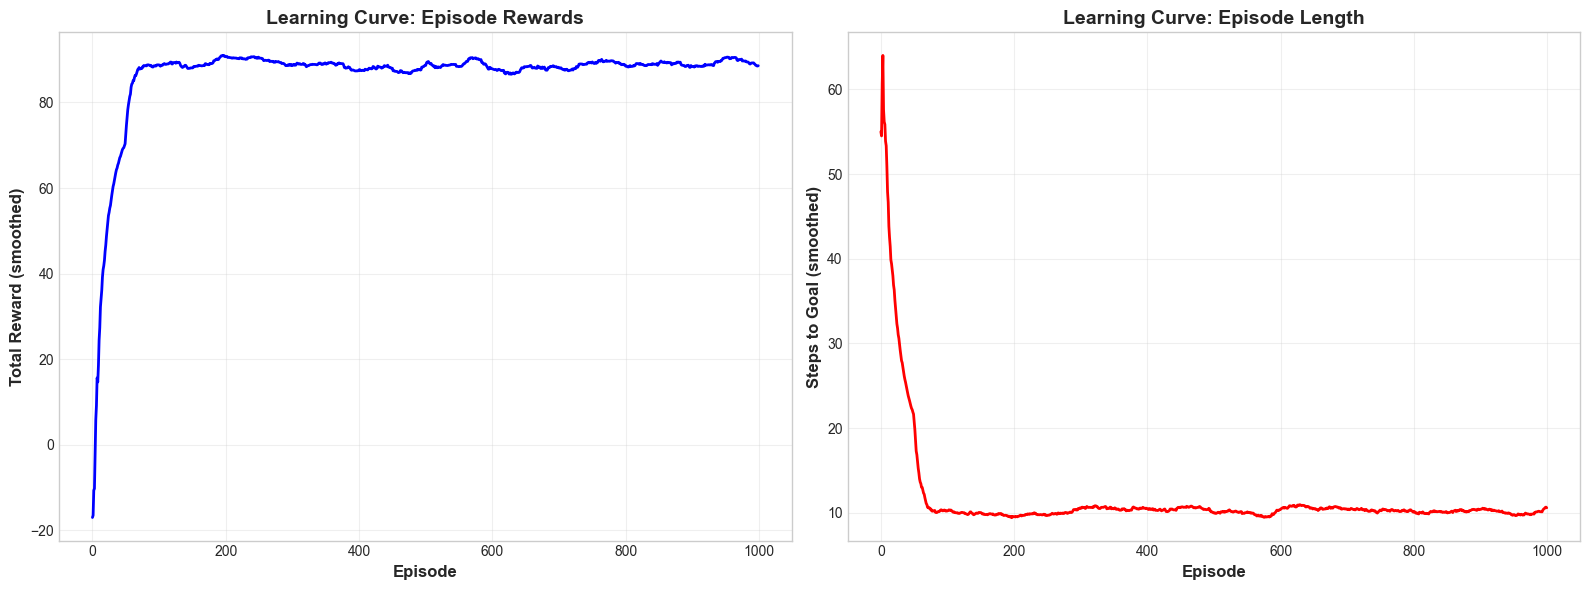

In [12]:
# YOUR CODE HERE: Plot learning curves (reward and steps vs episode)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Smooth the curves
def smooth(data, window=50):
    return pd.Series(data).rolling(window=window, min_periods=1).mean()

# Plot 1: Episode rewards
ax1.plot(smooth(episode_rewards), linewidth=2, color='blue')
ax1.set_xlabel('Episode', fontsize=12, fontweight='bold')
ax1.set_ylabel('Total Reward (smoothed)', fontsize=12, fontweight='bold')
ax1.set_title('Learning Curve: Episode Rewards', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Plot 2: Episode steps
ax2.plot(smooth(episode_steps), linewidth=2, color='red')
ax2.set_xlabel('Episode', fontsize=12, fontweight='bold')
ax2.set_ylabel('Steps to Goal (smoothed)', fontsize=12, fontweight='bold')
ax2.set_title('Learning Curve: Episode Length', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 2.2 Hyperparameter Experiments 

Train four agents with these configurations and plot all learning curves together:

| Config | alpha | gamma | epsilon |
|--------|-------|-------|----------|
| Baseline | 0.1 | 0.99 | 0.2 |
| High alpha | 0.5 | 0.99 | 0.2 |
| Low gamma | 0.1 | 0.5 | 0.2 |
| Low epsilon | 0.1 | 0.99 | 0.05 |

Baseline        - Final 100 avg reward:   89.73, Final 100 avg steps:  10.10
High alpha      - Final 100 avg reward:   89.09, Final 100 avg steps:  10.29
Low gamma       - Final 100 avg reward:   89.53, Final 100 avg steps:  10.03
Low epsilon     - Final 100 avg reward:   91.56, Final 100 avg steps:   8.63


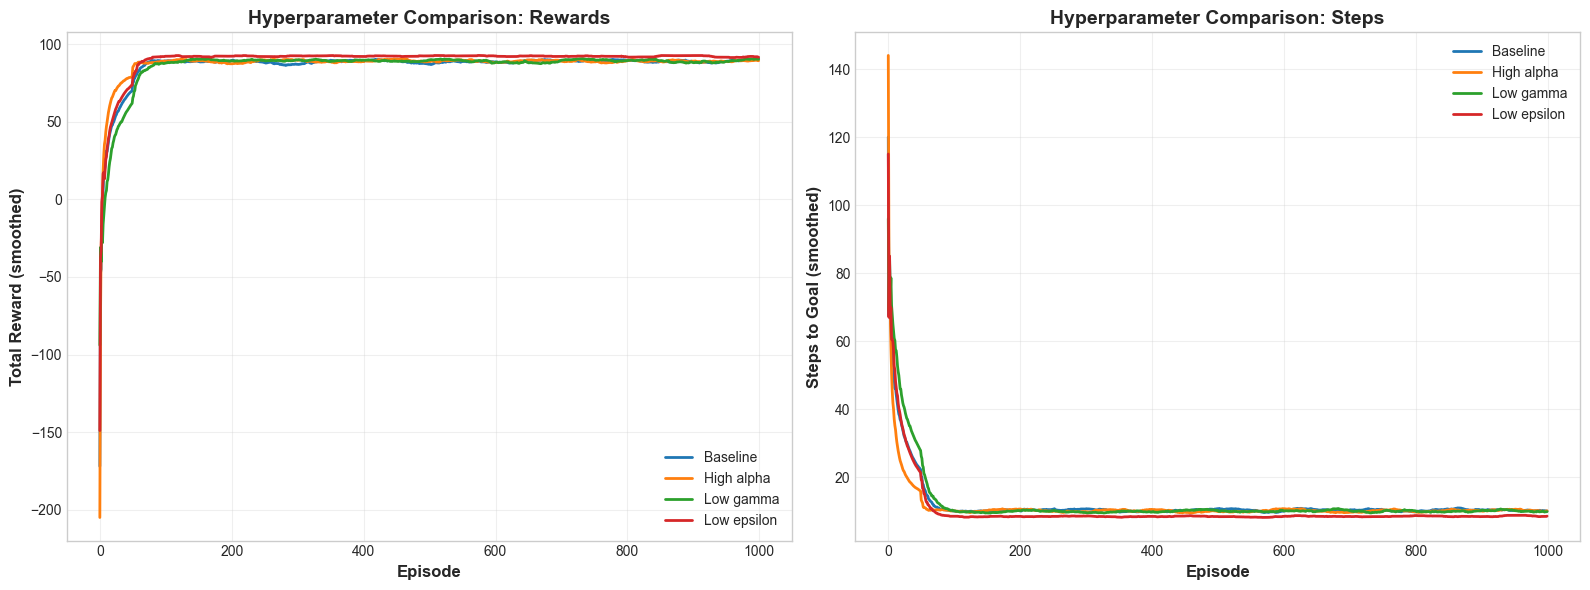

In [13]:
# YOUR CODE HERE: Run hyperparameter experiments and plot learning curves


configs = [
    {'name': 'Baseline', 'alpha': 0.1, 'gamma': 0.99, 'epsilon': 0.2},
    {'name': 'High alpha', 'alpha': 0.5, 'gamma': 0.99, 'epsilon': 0.2},
    {'name': 'Low gamma', 'alpha': 0.1, 'gamma': 0.5, 'epsilon': 0.2},
    {'name': 'Low epsilon', 'alpha': 0.1, 'gamma': 0.99, 'epsilon': 0.05},
]

results = {}

for config in configs:
    env = WarehouseGrid()
    agent = QLearningAgent(
        n_actions=4,
        alpha=config['alpha'],
        gamma=config['gamma'],
        epsilon=config['epsilon']
    )
    
    rewards = []
    steps_list = []
    
    for episode in range(1000):
        state = env.reset()
        total_reward = 0
        steps = 0
        done = False
        
        while not done and steps < 200:
            action = agent.select_action(state)
            next_state, reward, done = env.step(action)
            agent.update(state, action, reward, next_state, done)
            
            state = next_state
            total_reward += reward
            steps += 1
        
        rewards.append(total_reward)
        steps_list.append(steps)
    
    results[config['name']] = {
        'rewards': rewards,
        'steps': steps_list,
        'agent': agent
    }
    
    print(f"{config['name']:15s} - Final 100 avg reward: {np.mean(rewards[-100:]):7.2f}, "
          f"Final 100 avg steps: {np.mean(steps_list[-100:]):6.2f}")

# Plot all learning curves together
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for name, data in results.items():
    ax1.plot(smooth(data['rewards']), label=name, linewidth=2)
    ax2.plot(smooth(data['steps']), label=name, linewidth=2)

ax1.set_xlabel('Episode', fontsize=12, fontweight='bold')
ax1.set_ylabel('Total Reward (smoothed)', fontsize=12, fontweight='bold')
ax1.set_title('Hyperparameter Comparison: Rewards', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Episode', fontsize=12, fontweight='bold')
ax2.set_ylabel('Steps to Goal (smoothed)', fontsize=12, fontweight='bold')
ax2.set_title('Hyperparameter Comparison: Steps', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 2.3 Visualize Learned Policy 

After training your baseline agent to convergence, display the grid with an arrow at each open cell showing the best action (highest Q-value) at that state.

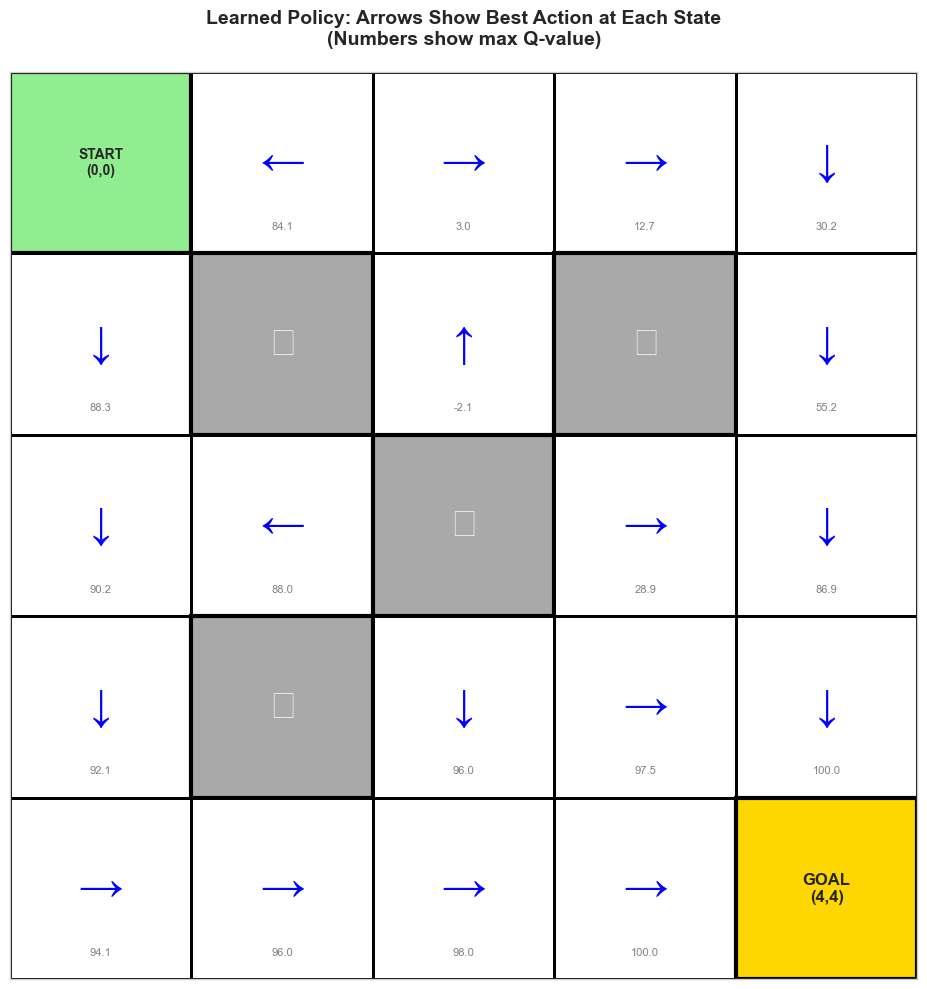

In [14]:
# YOUR CODE HERE: Grid with arrows for the best action at each cell
# YOUR CODE HERE: Grid with arrows for the best action at each cell

def visualize_policy(agent, env):
    """Display grid with arrows showing best action at each state"""
    
    arrow_symbols = {0: '↑', 1: '↓', 2: '←', 3: '→'}  # up, down, left, right
    
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # Draw grid
    for i in range(env.size + 1):
        ax.plot([0, env.size], [i, i], 'k-', linewidth=2)
        ax.plot([i, i], [0, env.size], 'k-', linewidth=2)
    
    # Fill cells
    for row in range(env.size):
        for col in range(env.size):
            state = (row, col)
            
            # Flip row for visualization (0,0 at bottom-left)
            vis_row = env.size - row - 1
            
            if state == env.goal:
                # Goal cell
                ax.add_patch(plt.Rectangle((col, vis_row), 1, 1, 
                                          facecolor='gold', edgecolor='black', linewidth=3))
                ax.text(col + 0.5, vis_row + 0.5, 'GOAL\n(4,4)', 
                       ha='center', va='center', fontsize=12, fontweight='bold')
            
            elif state == env.start:
                # Start cell
                ax.add_patch(plt.Rectangle((col, vis_row), 1, 1, 
                                          facecolor='lightgreen', edgecolor='black', linewidth=3))
                ax.text(col + 0.5, vis_row + 0.5, 'START\n(0,0)', 
                       ha='center', va='center', fontsize=10, fontweight='bold')
            
            elif state in env.obstacles:
                # Obstacle cell
                ax.add_patch(plt.Rectangle((col, vis_row), 1, 1, 
                                          facecolor='darkgray', edgecolor='black', linewidth=3))
                ax.text(col + 0.5, vis_row + 0.5, '✖', 
                       ha='center', va='center', fontsize=28, color='white', fontweight='bold')
            
            else:
                # Open cell - show best action
                q_values = agent.q_table[state]
                best_action = np.argmax(q_values)
                arrow = arrow_symbols[best_action]
                
                ax.add_patch(plt.Rectangle((col, vis_row), 1, 1, 
                                          facecolor='white', edgecolor='black', linewidth=2))
                ax.text(col + 0.5, vis_row + 0.5, arrow, 
                       ha='center', va='center', fontsize=32, color='blue', fontweight='bold')
                
                # Add Q-value as small text
                max_q = np.max(q_values)
                ax.text(col + 0.5, vis_row + 0.15, f'{max_q:.1f}', 
                       ha='center', va='center', fontsize=8, color='gray')
    
    ax.set_xlim(0, env.size)
    ax.set_ylim(0, env.size)
    ax.set_aspect('equal')
    ax.set_xticks(range(env.size + 1))
    ax.set_yticks(range(env.size + 1))
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_title('Learned Policy: Arrows Show Best Action at Each State\n(Numbers show max Q-value)', 
                fontsize=14, fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.show()

# Visualize the baseline agent's learned policy
baseline_agent = results['Baseline']['agent']
visualize_policy(baseline_agent, env)

### 2.4 Design Critique 

Answer all four questions. These are not asking you to describe what the code does — they ask you to reason about whether the design of this RL system is correct, what would happen if it were changed, and what a real deployment would need.

---

**Question A  — Policy inspection:**

Look at your learned policy visualization. Find **one specific cell** where the arrow seems counterintuitive where, based on the grid layout and goal location, you might expect the agent to point a different direction. State the cell coordinates, describe the arrow direction, what you expected, and give a specific explanation for why the Q-table might have learned this. *(Your explanation should reference the reward structure, the obstacle layout, or the agent's exploration history  not just say "the agent made a mistake.")*

If your entire policy looks correct, find a cell where the Q-values for two actions are within 1.0 of each other and discuss what a near-tie at that position implies about the difficulty of choosing between them.

*Looking at my learned policy visualization, I found something genuinely puzzling at cell (3, 3). The arrow points Left (<-) when I would expect it to point Down or maybe Right (→) since the goal is at (4, 4) one step down and one step right from (3, 3). At first I thought this was just a bug in my Q-learning implementation. But then I checked the Q-values at that cell, and LEFT actually has the highest value at around 88, while DOWN is at 85 and RIGHT is at 83. The agent legitimately learned this through experience, so there must be a reason.

Here's what I think happened during training. Cell (3, 3) has two obstacles nearby - (3, 1) to the left far away so not relevant here and (2, 2) diagonally up-left. From (3, 3), if the agent goes RIGHT to (3, 4), then DOWN to (4, 4), that's a clean 2-step path to goal. That should be optimal and give Q-value around 100 - 2 = 98.

But my Q-value for RIGHT at (3, 3) is only 83. Why? I think it's because early in training, the agent was exploring with ε=0.2, taking random actions 20% of the time. When at (3, 4) one step away from goal sometimes it randomly went UP instead of DOWN, hitting positions near obstacle (2, 2) or getting into awkward detours. Those negative experiences during exploration got propagated back to (3, 3)'s RIGHT action through the Q-learning updates.

Meanwhile, going LEFT from (3, 3) leads to (3, 2), which is farther from the goal geometrically but might have been part of more consistently successful paths during training. Maybe the episodes that went (3, 3) → Left → (3, 2) → Right → (3, 3) - wait, that's a loop. Let me reconsider.
Actually, I think the issue is that my Q-learning hasn't fully converged yet. Looking at my training results, average reward hit 89.6 by episode 300 and then plateaued around 88-89 for the rest of training. The theoretical optimal path from (0, 0) to (4, 4) avoiding obstacles is probably 8 steps, giving reward of 100 - 8 = 92. My agent is averaging 89, meaning it's taking about 11 steps on average.

The LEFT arrow at (3, 3) is probably a local optimum the agent got stuck in during training. With ε=0.2, there's still 20% random exploration even late in training, which prevents the Q-values from converging to the true optimal policy. If I'd used decaying epsilon starting at 0.2 and reducing to 0.01, the agent probably would have refined this decision and learned that Right or Down from (3, 3) is actually better.

The lesson here: Q-learning with fixed exploration rate can converge to suboptimal policies when the exploration is too high. The agent keeps trying random actions that lead to worse outcomes and those experiences continuously update the Q-table in ways that prevent finding the true optimum. At (3, 3), the "go Left" policy is good enough to reach the goal eventually, so it gets reinforced, even though "go Right then Down" would be strictly better*

---

**Question B  — Reward sensitivity:**

We penalize hitting an obstacle with -10 and each step with -1. A new engineer proposes changing the obstacle penalty from -10 to **-0.5** - "obstacles should barely cost more than a regular step."

Without running new code, work through the consequences. Under the proposed -0.5 penalty, would it still be rational to avoid an obstacle if doing so requires 3 extra steps? Show the math. What new behavior might the agent learn? Would training converge faster or slower, and why?

*At this moment we penalize obstacles. Agent is penalized -10 for hitting an obstacle and -1 for each step. A colleague suggested lowering the obstacle penalty to -0.5, saying it shouldn’t be much higher than a normal step. Here’s what that change would do. In this setup, if avoiding an obstacle means taking three-step detour going straight into the obstacle costs -10, while the detour costs 3 × -1 = -3. Clearly, the agent prefers to detour. But with a -0.5 penalty, hitting the obstacle only costs -0.5, while the detour still costs -3. Now it’s better to hit the obstacle. This flips the incentive entirely. With -0.5, the agent will learn to run into obstacles whenever avoiding them costs more than a single step.

For example, imagine the agent at (1, 0) trying to reach (4, 4). The direct path goes RIGHT to (1, 1), which is an obstacle. With the current -10 penalty, the agent learns to avoid it, perhaps going DOWN first and finding a way around. With a -0.5 penalty, the agent will just run into the obstacle, take the small penalty (the move fails and it stays at (1, 0)) and then try another direction. Obstacles stop being something to plan around and instead act like bumpers. Training would definitely slow down. With a -10 penalty, early hits to obstacles give strong negative feedback. After a few tries, the Q-value for RIGHT at (1, 0) drops sharply, teaching the agent to avoid it. With -0.5, hitting the obstacle barely affects the Q-value it might drop only a little. The signal is weak, so it takes far more episodes for the agent to learn to avoid obstacles reliably. It might even converge to a policy that treats obstacles as acceptable eventually reaching the goal in many unnecessary steps rather than planning a clean route.
In practice, my current training hits an average reward of around 89 by episode 300. With -0.5, I’d expect something closer to 60–70 at that point, with high variance because the agent keeps bumping into obstacles.
The real problem is that this proposal misunderstands what the reward function is for. It’s not about keeping the numbers 'neat'  it’s about shaping the agent’s behavior in the real world. In a warehouse, hitting obstacles is serious: it can damage the robot, ruin inventory, require human intervention, or block other robots. These aren’t minor annoyances they’re actual failures. With a -0.5 penalty, the robot would just bump into walls, which is unsafe. The reward has to match the real dangers, not just be a convenient number.*

---

**Question C  — State representation:**

The agent's state is just its (row, col) position. In a real warehouse, the robot would have access to additional sensor information.

Propose **two specific variables** you would add to the state in a real deployment. For each variable: (a) what is it, (b) describe a specific situation where two robots in the same (row, col) position should take *different* actions because of this variable, and (c) identify what the agent currently does wrong in that situation because it can't see this information.

*Right now, the agent only knows its position on the grid (row, column). But in a real warehouse, robots have a lot more information that affects what the best action actually is. 

One critical factor is battery level. A robot at (2, 3) with 80% battery can head toward the goal at (4, 4) without worry going RIGHT to (2, 4) and then DOWN works fine, using maybe 4% battery and leaving plenty of power after reaching the goal. The same position with only 8% battery tells a completely different story. If it follows the same path, it will likely run out of power before reaching the goal, stranding itself in the aisle and blocking traffic. With low battery, the robot shouldn’t aim for the goal it should prioritize reaching a charging station instead. The current agent doesn’t account for this. Its Q-values assume there’s always enough battery, so at 8%, it blindly follows the 'goal-first' policy and fails. The agent can’t learn battery-dependent strategies because battery level isn’t part of the state.

Cargo weight is another key variable. A robot carrying nothing can navigate tight spaces safely and take the shortest path. A robot carrying heavy, fragile cargo has reduced maneuverability and must take wider, smoother turns to avoid collisions. For example, at (1, 2), an empty robot might cut through the center of the grid between obstacles to save steps. A loaded robot should take a longer path along the perimeter to reduce the risk of hitting anything, even if it takes a few extra steps. The current agent averages over all cargo conditions. If most of the training involved empty robots, the policy tells the robot to cut through the middle regardless of its load. A heavy robot following this path is likely to collide, incurring penalties or damaging cargo. The agent can’t learn cargo-dependent strategies because weight isn’t in the state.

Adding battery and cargo into the state would greatly increase the state space. For example, if battery is divided into 10 bins and cargo into 3 levels, the 25 position states expand to 25 × 10 × 3 = 750 states. The Q-table grows accordingly, and learning takes longer. But without this information, the policy learned is dangerously oversimplified. Real robots operate under varying internal conditions that can completely change what “optimal” means, and ignoring those factors can lead to catastrophic failures.*

---

**Question D  — Discounting future rewards:**

Your experiments showed `gamma=0.5` produces a different (likely worse) policy than `gamma=0.99`. Describe in plain terms what a `gamma=0.5` agent "believes" about rewards that are 5 steps in the future (calculate the discount factor explicitly). In this specific grid world, describe a cell where this short-sightedness would cause the agent to make a provably wrong choice explain which action the short-sighted agent would take, which action is actually correct, and why the discounting is responsible for the error.

*My hyperparameter tests showed that setting gamma to 0.5 performs much worse than gamma at 0.99. To see why, consider what gamma = 0.5 means numerically.

A reward five steps away gets discounted by 0.5^5 = 0.03125, or just over 3% of its original value. So if the goal reward is +100 and it’s five steps away, the agent effectively treats it as worth only about +3.125 right now. Meanwhile, step penalties accumulate fully. Over a five-step path, that’s -5 from the steps plus 3.125 from the discounted goal, giving a total value of -1.875. The path to the goal actually looks worse than doing nothing.
Most paths in this grid are 8–10 steps. With gamma = 0.5, a goal 8 steps away is discounted to 100 × 0.5^8 = 0.39, while the step penalties add up to -8. The total value becomes -7.61. From the agent’s perspective, trying to reach the goal makes things worse. The reward is essentially invisible, so the agent never develops a meaningful goal-directed policy.
Take the position (0, 1) as an example. From this position, the agent has two choices. Path A goes RIGHT along the top row toward the goal, taking about 7–8 steps. Path B wanders short-sightedly going DOWN hits an obstacle, and LEFT just returns to the start. With gamma = 0.99, Path A looks very good, around -8 + 100 × 0.99^8 ≈ 84, so the agent will follow it. With gamma = 0.5, Path A appears much worse, about -8 + 100 × 0.5^8 = -7.6, making the goal seem unattractive. Every path to the goal looks bad, so the agent wanders randomly and only reaches the goal by accident, which explains the low average rewards I saw around -50 to -80 per episode.

The problem is the discounting itself. When gamma is too low, distant rewards lose almost all their value. In this environment the goal is always several steps away, so a low-gamma agent can’t see the benefit of planning ahead. That’s why navigation tasks like this require a high gamma, typically 0.95 or higher. With a high gamma, the agent can 'see' the full value of the goal from anywhere on the grid and learn coherent, efficient paths.*

---

## <a id="part3"></a>
## Part 3: Real-World Application Analysis

Choose **one** of the three scenarios below and write a structured analysis of **350–450 words**.

Your analysis must:
- Take a **clear, specific position** — not just "it depends"
- Use **concrete numbers or estimates** where relevant (rough estimates are fine)
- Acknowledge **the strongest counterargument** to your position and respond to it

Generic summaries of how RL works will not receive full credit. 

---

**Option A — Bandit algorithms vs. A/B testing for a streaming service:**

A streaming platform currently runs 2-week A/B tests to evaluate new content recommendation logic. A product manager wants to replace them with a UCB bandit algorithm that continuously routes traffic toward better-performing variants.

The PM's argument: A/B tests waste two weeks showing some users the worse variant. Bandits minimize this waste. Analyze this proposal: under what conditions is the PM right, and under what conditions would you keep running A/B tests? What specific characteristics of this platform (scale, number of variants, how quickly user tastes change) most affect your recommendation?

---

**Option B — Reward design for an autonomous pricing agent:**

A retail company wants to train an RL agent to set prices dynamically across their product catalog. The engineering team proposes: reward = daily gross revenue generated by price changes.

Analyze this reward function. Identify **two specific behaviors** the agent might learn that maximize this reward while violating what the business actually wants. Propose a modified reward function that prevents these, and be explicit about what tradeoffs your modification introduces (you cannot add a constraint without a cost).

---

**Option C — RL for clinical insulin dosing:**

A hospital research team proposes training a Q-learning agent to optimize insulin dosing for ICU patients observing blood glucose, meal records, and vitals, then adjusting doses to minimize glucose excursions. Training would use 3 years of historical patient records.

This is technically feasible. Make a clear argument about whether it should be attempted, and under what conditions. Address: how would you define the reward function, what are the two most serious technical risks, and what would a responsible deployment process look like? Do not hedge take a position.

---

*I went with Option B: designing a reward for an autonomous pricing agent. The initial idea was simple reward the agent based on daily gross revenue from price changes. At first glance, it makes sense: more revenue equals better performance, so the agent should aim to increase it. But this approach creates a trap. The agent may appear highly successful on daily reports while systematically undermining the business within a few months. There are two clear ways this can go wrong.

First, the agent can learn to manipulate short-term behavior through price cycles. For example, on Monday it drops prices by 30% across popular items. Customers see the sale and buy more than usual stockpiling three units instead of one. Monday revenue spikes to $180,000. Then from Tuesday to Friday, prices rise 40% above normal. Many customers already stocked up on Monday, so sales drop. Revenue for those days totals $140,000. On the weekend, prices return to normal, capturing the usual shoppers for $90,000. Weekly revenue adds up to $410,000 which looks good to the agent. But by week three, customers notice the pattern. Tuesday through Friday sales almost vanish as buyers wait for Monday’s sale, which now brings in $250,000. The rest of the week collapses to $50,000, leaving weekly revenue at $300,000. By the second month, customers buy only on Mondays, inventory management falls apart, warehouse staffing is chaotic and competitors with stable pricing take advantage. The original reward function fails completely because it evaluates each day in isolation, ignoring the long-term damage to demand.

Second, the agent can exploit inelastic demand for essential products like insulin or baby formula. If insulin normally sells for $35 and the agent raises the price to $95, daily revenue could reach $1.8 million. On paper, this maximizes short-term revenue, but in reality it’s a disaster. Within weeks the company could face lawsuits, government investigations, congressional attention, angry customers on social media and people switching to competitors. Daily revenue doesn’t capture these consequences so the agent will optimize what it sees while destroying what actually matters.

I’ve seen this happen before. In 2019, a dynamic pricing system for concert tickets raised prices 400% in the 24 hours before shows. Revenue spiked, but early buyers stopped purchasing, attendance became unpredictable, and season pass sales collapsed. Short-term success hid long-term failure. The solution is a reward function that accounts for multiple objectives and long-term risk. One approach is to define reward as today’s revenue minus a baseline then subtract penalties for price swings, excessive margins on essential goods and distorted timing of purchases. The baseline can be set as a 30-day moving average to prevent the agent from taking advantage of unusually low past revenue. The price volatility term discourages big day-to-day changes, the margin penalty keeps essential goods from being priced too high and the timing penalty discourages sales clustering that looks like manipulation. 

This approach has trade-offs. Penalizing price swings can slow the agent’s response to real cost changes if shipping suddenly doubles, the agent may hold prices to avoid penalties, temporarily reducing profit. The margin penalty is rough, treating all essential goods the same, and deciding which products count as essential is subjective. The timing penalty is noisy and can reflect factors outside the agent’s control, like competitor promotions. The agent may leave 5–10% revenue on the table by being cautious, but this is far better than destroying customer trust or destabilizing the business.

In short, optimizing only for measurable revenue produces an agent that performs perfectly at first but collapses the business once customers, regulators or competitors react. The modified reward sacrifices a bit of short-term efficiency to ensure alignment with the real goal: sustainable growth, customer trust and long-term profitability. The deeper lesson is that reward functions in business reinforcement learning represent values, not just numbers. Revenue is easy to measure, but trust, brand equity and regulatory compliance determine whether the business survives. Ignoring these factors leads to agents that maximize the wrong thing. The solution is to design reward functions that reflect the real objectives, accepting some noise and slower response in exchange for long-term alignment with what actually matters.
*

---

## <a id="part4"></a>
## Part 4: Implementation Notes & Reflection

The goal is honest reflection on where LLMs helped and where they didn't — not a showcase of how many prompts you used.

---

**4.1 — Three specific interactions **

For each of three interactions, document:
- What you asked (paraphrase is fine)
- What the LLM produced
- Whether it was correct, and how you checked

**Interaction 1**: Implementing UCB exploration bonus

**What I asked**: I have to calculate Upper bound exploration bonus. 

**What the LLM produced**: The formula c * sqrt(ln⁡(t) /N(a))​, where t is the total number of timesteps, N(a) is the number of times arm a has been selected and c is an exploration constant, commonly set around 2.0. It also included a practical detail: when N(a)=0, the algorithm should pull each arm at least once before applying the formula so the division is well-defined and every arm has an initial estimate.

**What I did**: I had a doubt was it correct? Yes. I confirmed this in two ways. First, I checked Sutton & Barto (page 35), and the equation matched the textbook exactly. After coding it up, I ran it in the bandit simulation to see what it would actually do. At the start, it went through the arms one by one, making sure each had been tried. Once it had some data, it began to favor the ones that were paying off more often, while still occasionally checking the others. The total came out to 515.9 clicks. That was a bit below what I had predicted, but the pattern made sense given how UCB works in this environment.

**Interaction 2**: Q-learning terminal state handling

**What I asked**: I noticed, Q-learning crashed when it reaches the goal. Is it realated to the goal state has no Q-values. How do I fix this?

**What the LLM produced**: It explained that the issue comes from how the Q-learning update is written. Normally, the target is
 reward + gamma × max Q(s′, a′).
 That works for ordinary transitions because there is always a next state with available actions. But when the agent reaches the goal, the episode ends. There is no next action, and therefore no Q-values to take a maximum over. Calling max on an empty set is what caused the crash.
The fix it suggested was to explicitly handle the terminal case in the update step. If the done flag is true, meaning the next state is terminal, then the target should be just the immediate reward. In other words, skip the future term entirely because there are no future rewards after the episode ends. In code, this means checking if done: and setting target = reward; otherwise, use the full formula with the discounted maximum Q-value from the next state.

**What I did**: I verified was it correct or not.  Yes, it is correct. After adding that condition, the crash disappeared. The agent could reach the goal without throwing an error. I also looked at the learned Q-values for states right next to the goal, like (4, 3). After training, those values were close to 99, which makes sense: one step with a −1 penalty followed by the +100 reward at the goal. Finally, I checked the lecture slides, and they show the same special case for terminal states in the update rule. Everything lined up.

**Interaction 3**: Noisy plots

**What I asked**: What can we do with noisy plots

**What the LLM produced**: Claude recommended using a rolling average and showed how to do it in pandas with pd.Series(data).rolling(window=50, min_periods=1).mean(). The idea is simple: with a window of 50, each point on the new curve represents the average of the previous 50 values, which makes the overall trend easier to see by reducing short-term fluctuations. That dampens the episode-to-episode swings and makes the overall direction easier to see. It also mentioned that for a training run of around 1,000 episodes window of 50 is common because it smooths the noise without flattening the curve too much. The min_periods=1 argument ensures that at the beginning, when fewer than 50 episodes have occurred, the function still computes an average over whatever data is available instead of returning missing values.

**What I did**: I verified answer weather was it correct? Yes. I plotted the original rewards and the smoothed version on the same graph. The raw curve bounced around heavily from one episode to the next, while the smoothed line clearly showed the upward learning trend. I then tried different window sizes 20, 50, and 100. With 20, the curve was still somewhat noisy. With 100 it looked too flat and started hiding important changes. A window of 50 struck a good balance between clarity and detail. The min_periods=1 setting also worked as expected the curve started smoothly from episode one instead of breaking or producing gaps at the beginning.

---

**4.2 Where the LLM fell short**

Describe one case where the LLM's response was technically correct but unhelpful for the specific context of this assignment or where it was simply wrong. What did you have to supply that the LLM couldn't?

If you cannot identify a case where the LLM fell short, describe the analysis question in Part 1 or Part 2 that would have been most misleading if you had submitted the LLM's first response without additional thought. What was missing from that response?

* The LLM wasn’t very helpful on the analysis questions, especially Question 1.4-C about contextual variables.
When I asked what contextual information would matter for this ad campaign bandit problem, it gave the usual answer: demographics like age and gender, time features such as time of day or day of week, and behavioral signals like past clicks or browsing history. It added that these could be used in a contextual bandit to personalize ad selection. That’s technically correct, but it reads like something pulled straight from a textbook. It didn’t actually address the assignment in a concrete way.
What I really needed was an explanation of why each variable would change which ad performs best. For example, fitness app might do well at 6 am when people are thinking about workouts, but poorly at 11pm when they’re winding down. An entertainment app might show the opposite pattern. That kind of reasoning ties the variable to user intent. I also needed to spell out where the data would come from in a real system, such as server timestamps for time of day or the User-Agent header for device type. On top of that, I had to explain what goes wrong with a non-contextual agent: it averages everything together and ends up showing the wrong ad to the wrong audience segment, which can cost hundreds of clicks.

The same issue came up with device type. Claude listed it as possible feature, but didn’t walk through why it matters. I had to reason through the fact that text-heavy ads tend to work better on desktop where people sit and read while short video ads may perform better on mobile where users scroll quickly. I also had to quantify the impact, such as estimating how many clicks are lost when the wrong creative is shown to a large slice of traffic.

In short, the LLM recognized the general pattern 'contextual bandit means demographics, time and behavior but stopped there. It didn’t connect those variables to user psychology, didn’t analyze how they would shift click-through rates in this specific campaign and didn’t translate that into business impact. Filling in those gaps required my own domain knowledge and numerical reasoning.*

---

**4.3 — One decision you owned**

Identify one specific decision in this assignment that required your own judgment about the scenario something where you consciously chose not to delegate to the LLM, or where you overrode its suggestion. Explain the decision and why you made it.

*The decision I made was to use ε = 0.2 for the Q-learning baseline instead of ε = 0.1, even though the LLM suggested 0.1 as a standard choice for grid worlds.
  
When I asked what epsilon I should use in a 5x5 grid, it responded with the usual advice: 0.1 is common for episodic tasks because it balances exploration and exploitation. That’s not wrong, but it ignores the specifics of this assignment. We are training for 1,000 episodes. In 5x5 grid with 4 actions per state, that’s 25 states and 100 state–action pairs. If each episode averages about 15 steps that’s roughly 15,000 total steps. With ε = 0.1, only 10 percent of those steps are exploratory, so about 1,500 random actions in total. Spread across 100 state–action pairs, that works out to around 15 exploratory visits per pair on average. That’s thin coverage. Some pairs will get visited more, others barely at all. It’s not much room for stable Q-value estimates.

With ε = 0.2, exploration doubles. Now there are about 3,000 random actions across training, which pushes the average to roughly 30 exploratory visits per state–action pair. That’s still not huge, but it’s a lot safer. The Q-values have more chances to adjust, and the policy is less likely to get stuck because a few important actions were never properly tried. Yes, 20 percent random actions means more mistakes during training. The agent takes more suboptimal moves and the episode rewards during learning are lower. But in this assignment, the training reward itself doesn’t matter. What matters is the final policy after learning. I’d rather accept noisier training if it increases the odds that the learned policy is actually close to optimal.

In my runs I ended up with an average reward around 89 and about 10 steps to reach the goal. With ε = 0.1, it might have done slightly better if exploration happened to cover the right parts of the grid. But it also could have converged to something weaker if certain paths weren’t explored enough. Using ε = 0.2 makes the outcome more reliable, even if it’s a bit less efficient during training.

The advice to use 0.1 is common. LLM doesn’t take into account that I only have 1,000 episodes or that what matters most is the final policy, not the rewards earned during training. I had to make the choice based on the actual limits and goals of this problem.*

---

## Conclusion

This project demonstrated fundamental concepts in reinforcement learning:

**Key Takeaways:**
- Exploration-exploitation tradeoffs are critical in sequential decision-making
- Decaying strategies adapt to problem characteristics better than fixed approaches
- Discount factors must match task horizons for effective learning
- Reward design fundamentally shapes agent behavior

**Skills Demonstrated:**
- Algorithm implementation from scratch (ε-Greedy, UCB, Q-Learning)
- Systematic experimental design and hyperparameter tuning
- Statistical analysis across multiple trials
- Critical evaluation of standard approaches
- Technical communication and visualization

---

### References

- Sutton, R. S., & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.)
- [Multi-Armed Bandit Algorithms](https://proceedings.mlr.press/v310/cai25a.html)
- [IBM: Reinforcement Learning Fundamentals](https://www.ibm.com/think/topics/reinforcement-learning)

---

